In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import entropy
from tqdm import tqdm


In [2]:
root_dir = os.getcwd()
data_dir = os.path.join(root_dir, "Data")
dataset_path = os.path.join(data_dir, "housing.csv")


In [3]:
housing_data = pd.read_csv(dataset_path)
housing_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
housing_data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [5]:
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
housing_data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
Housing_data = housing_data[["area", "price"]]
Housing_data.head()

,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


In [8]:
Housing_data.columns = ["Area", "Price"]

In [9]:
Housing_data.head()

,Area,Price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


In [10]:
def normalization(col):
    Mean = col.mean()
    Std = col.std()
    return (col - Mean) / Std
Housing_data = Housing_data[["Area", "Price"]].agg(normalization)
Housing_data.head()

,Area,Price
0,1.045766,4.562174
1,1.755397,4.000809
2,2.216196,4.000809
3,1.082630,3.982096
4,1.045766,3.551716


In [11]:
def get_house_price(x, w, b):
    y_pred = x * w + b
    return y_pred

In [12]:
w = np.random.randint(100, 200)
b = np.random.randint(100, 200)
print(w, b)

111 179


In [13]:
Housing_data["Random Pred data"] = get_house_price(Housing_data["Area"], w, b)
Housing_data.head()

,Area,Price,Random Pred data
0,1.045766,4.562174,295.079976
1,1.755397,4.000809,373.849050
2,2.216196,4.000809,424.997800
3,1.082630,3.982096,299.171876
4,1.045766,3.551716,295.079976


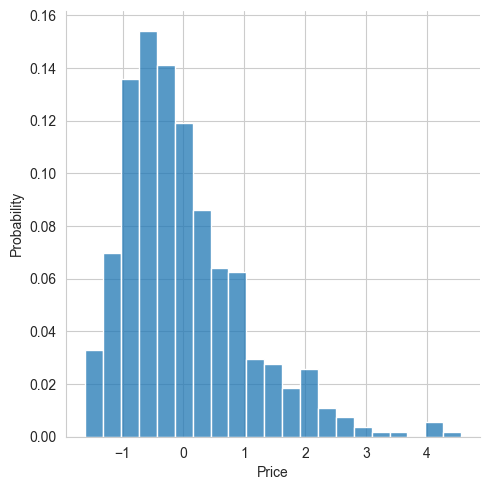

In [14]:
sns.displot(
    data= Housing_data,
    x = "Price",
    fill = True,
    kind= "hist",
    stat = "probability",
)

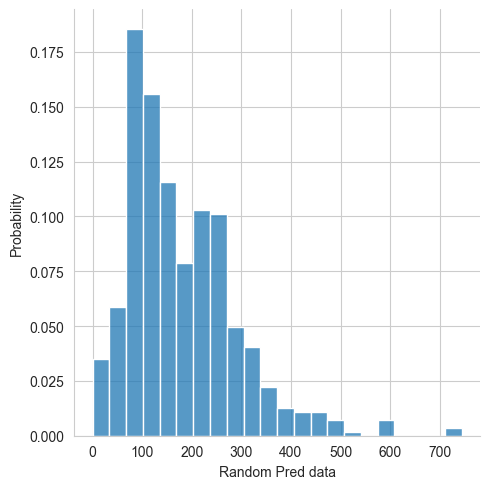

In [15]:
sns.displot(
    data= Housing_data,
    x = "Random Pred data",
    fill = True,
    kind= "hist",
    stat = "probability",
)

In [16]:
def cost_function(x, y_true, w, b):
    y_pred = get_house_price(x, w, b)
    mse = np.mean((y_true - y_pred) **2) /2
    return mse

x = Housing_data["Area"]
y_true = Housing_data["Price"]
loss = cost_function(x, y_true, w, b)
print(loss)

22110.80887389456


In [17]:
loss1 = cost_function(x, y_true, w = 100, b = 125)
print(loss1)
loss2 = cost_function(x, y_true, w = 125, b = 140)
print(loss2)
loss3 = cost_function(x, y_true, w = 140, b = 160)
print(loss3)
loss4 = cost_function(x, y_true, w = 90, b = 100)
print(loss4)

12750.323384201232
17531.787487132275
22507.615490175303
8994.916642111382


In [18]:
weights = np.linspace(-10, 10, 100)
biases = np.linspace(-10, 10, 100)
weight_mesh , bias_mesh = np.meshgrid(weights, biases)
losses_mesh = []
for w in tqdm(np.ravel(weight_mesh[0])):
    for b in np.ravel(bias_mesh[0]):
        loss = cost_function(x, y_true, w, b)
        losses_mesh.append(loss)

losses_mesh = np.array(losses_mesh)
losses_mesh = losses_mesh.reshape(weight_mesh.shape)

100%|██████████| 100/100 [00:02<00:00, 44.94it/s]


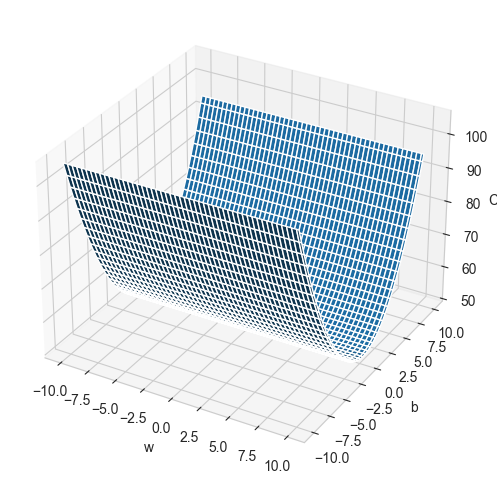

In [19]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection= "3d")
ax.plot_surface(weight_mesh, bias_mesh, losses_mesh)
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("Cost")
plt.show()

In [22]:
"""Gradient descent algorithm
- compute gradients
- update parameters"""
def compute_gradient(x, y_true, w, b):
    delta = 1e-9
    cost_1 = cost_function(x, y_true, w, b)
    cost_2 = cost_function(x, y_true, w + delta, b)
    cost_3 = cost_function(x, y_true, w, b + delta)
    dw = (cost_2 - cost_1) / delta
    db = (cost_3 - cost_1) / delta
    return dw, db

In [20]:
print(w, b)

10.0 -10.0


In [23]:
loss = cost_function(x, y_true, w, b)
print(loss)

95.0572008054445


In [24]:
dw, db = compute_gradient(x, y_true, w, b)
print(dw, db)

9.446637250221102 -9.999993721976352


In [27]:
learning_rate = 0.001
w = w - learning_rate * dw
b = b - learning_rate * db

In [25]:
loss = cost_function(x, y_true, w, b)
print(loss)

95.0572008054445


In [41]:
for epoch in range(10000):
    loss = cost_function(x, y_true, w, b)
    dw, db = compute_gradient(x, y_true, w, b)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if epoch % 100 == 0:
        print(loss)



0.3556997594413074
0.35569972387549104
0.35569969475444163
0.3556996709104434
0.35569965138694776
0.3556996354011952
0.35569962231223146
0.3556996115950206
0.3556996028197708
0.3556995956347184
0.35569958975172605
0.35569958493470577
0.3556995809903446
0.3556995777609386
0.35569957511675754
0.3556995729516152
0.3556995711788716
0.3556995697272952
0.35569956853883433
0.3556995675656979
0.3556995667688819
0.35569956611644526
0.35569956558223853
0.35569956514480505
0.35569956478663867
0.35569956449339896
0.35569956425329247
0.3556995640566829
0.3556995638957169
0.355699563763924
0.35569956365600114
0.35569956356766114
0.35569956349531173
0.35569956343605674
0.35569956338754194
0.3556995633478295
0.35569956331531
0.35569956328866925
0.3556995632668645
0.3556995632490087
0.35569956323438834
0.35569956322241175
0.3556995632126123
0.35569956320458823
0.3556995631980155
0.35569956319263707
0.3556995631882284
0.35569956318461765
0.3556995631816611
0.3556995631792444
0.3556995631772648
0.3556995

In [42]:
print(w, b)

0.5359974274321466 -8.758659575391903e-08


In [46]:
Housing_data["Price_pred_learned"] = get_house_price(Housing_data["Area"], w, b)
Housing_data.head()

,Area,Price,Random Pred data,Price_pred_learned
0,1.045766,4.562174,295.079976,0.560528
1,1.755397,4.000809,373.849050,0.940888
2,2.216196,4.000809,424.997800,1.187875
3,1.082630,3.982096,299.171876,0.580287
4,1.045766,3.551716,295.079976,0.560528
